In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt

from langchain_tavily import TavilySearch
from langchain.chat_models import init_chat_model
from langchain_ollama import ChatOllama

import os
os.environ["TAVILY_API_KEY"] = "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"

: 

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)


# llm = init_chat_model("anthropic:claude-3-5-sonnet-latest") # 改成本地部署的模型
llm = ChatOllama(base_url="http://localhost:11434", model="qwen3:14b")

tool = TavilySearch(max_results=2)
tools = [tool]
llm_with_tools = llm.bind_tools(tools)

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

def chatbot(state: State):
    print("assistant: ", end="", flush=True)

    chunks = []
    tool_calls = []

    # 遍历流式输出
    for chunk in llm_with_tools.stream(state["messages"]):
        # 打印调试用
        # print("DEBUG:", chunk)

        # 处理自然语言内容
        if chunk.content:
            print(chunk.content, end="", flush=True)
            chunks.append(chunk.content)

        # 处理工具调用
        if getattr(chunk, "tool_calls", None):
            for tc in chunk.tool_calls:
                print(f"\n[Tool call] name={tc['name']} args={tc['args']}", flush=True)
                tool_calls.append(tc)

    messages = []
    if chunks:
        messages.append({"role": "assistant", "content": "".join(chunks)})
    if tool_calls:
        messages.append({"role": "assistant", "content": "", "tool_calls": tool_calls})
    assert len(messages.tool_calls) <= 1
    return {"messages": messages}


# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)
tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)


graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = InMemorySaver()
graph = graph_builder.compile(checkpointer=memory)


assistant: <think>
好的，用户让我介绍一下杭州运河广场周边有什么适合两人聚会的活动。首先，我需要确定用户的需求是什么。他们可能是在寻找浪漫的约会地点，或者朋友间的聚会场所。运河广场位于杭州，可能有一些文化、休闲或者餐饮场所。

接下来，我需要考虑使用哪个工具来获取信息。用户提供的工具是tavily_search，这是一个搜索引擎，可以查找实时信息。因此，我应该用这个工具来搜索杭州运河广场周边的活动。

然后，我需要构造搜索查询。用户的问题是关于周边的两人聚会活动，所以关键词可能包括“杭州运河广场 周边 聚会 活动”或者“杭州运河广场 两人 约会 地点”。可能需要调整关键词以获得更准确的结果。

另外，可能需要考虑时间因素，比如是否有近期的活动或者长期存在的场所。用户的问题中没有提到时间范围，所以可能不需要使用start_date或end_date参数，但如果有需要的话，可以进一步调整。

还要注意是否需要排除某些类型的结果，比如用户可能不希望看到广告或者不相关的网站，但根据问题描述，暂时不需要使用exclude_domains或include_domains参数。

搜索深度方面，可能需要使用“advanced”来获取更详细的信息，比如具体的活动名称、地点、时间等。同时，是否需要包含图片？用户可能希望看到一些视觉信息，但如果没有特别要求，可能保持默认。

最后，确定搜索的topic是否需要指定，比如“general”或者“events”，但根据工具描述，topic参数默认是“general”，所以可能不需要特别设置。

综上所述，我应该使用tavily_search函数，构造合适的查询词，可能包括“杭州运河广场 周边 两人聚会 活动”，并设置search_depth为“advanced”以获取更详细的信息。然后根据返回的结果，整理出适合两人聚会的活动，如餐厅、咖啡馆、文化场所、公园等，并可能包括具体的活动名称和时间。
</think>


[Tool call] name=tavily_search args={'query': '杭州运河广场 周边 两人聚会 活动', 'search_depth': 'advanced'}
assistant: <think>
好的，我现在需要处理用户关于杭州运河广场附近适合两人约会的地点推荐的问题。首先，我得仔

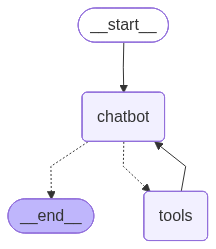

In [14]:
user_input = {"role": "user", "content": "杭州运河广场介绍一下周边有什么时候两人聚会的活动"}
    
    # 执行图
final_state = graph.invoke({"messages": [user_input]})

print("对话历史:")
for msg in final_state["messages"]:
    print(f"{msg.type}: {msg.content}")

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass